In [71]:
import pandas as pd
import networkx as nx
import ast
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt


Primero se genera el grafo bipartito con 2 conjuntos, personas y episodios. Un link entre una persona y episodio existe solo si esta trabajo en la produccion del capitulo.

In [72]:
# Cargar CSV
df = pd.read_csv("datasets/one_piece_merged.csv")

# Columnas donde hay listas de personas
staff_columns = ["guion", "arte", "animacion", "direccion"]
value_columns = ["n de paginas", "rating", "votos"]

# Función para convertir string de lista a lista real
def parse_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

# Crear grafo bipartito
B = nx.Graph()

for _, row in df.iterrows():
    episodio = f"ep_{int(row['episodio'])}"
    
    # Agregar nodo episodio
    B.add_node(episodio, bipartite="episode")

    value_dict = {}
    for val in value_columns:
        value_dict[val] = row[val]
    
    nx.set_node_attributes(B, {episodio: value_dict})

    # Iterar por todas las áreas del staff
    for col in staff_columns:
        personas = parse_list(row[col])
        
        for persona in personas:
            persona_clean = persona.split("(")[0].strip()

            # Agregar nodo persona
            if persona_clean == '' or persona_clean == "N/A":
                continue
            B.add_node(persona_clean, bipartite="staff")

            # Agregar arista
            B.add_edge(persona_clean, episodio)


print(f"Number of nodes: {B.number_of_nodes()}, Number of edges: {B.number_of_edges()}")
nx.write_gexf(B, "one_piece.gexf")

Number of nodes: 1384, Number of edges: 5176


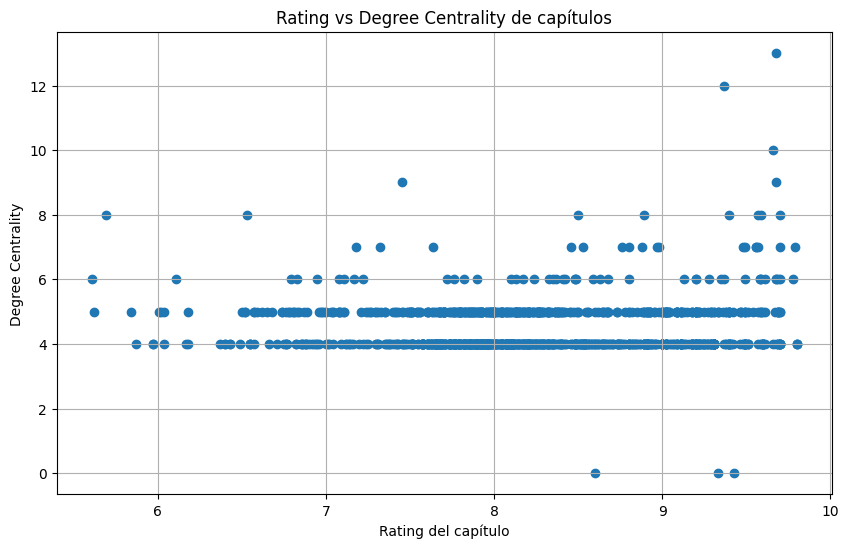

In [73]:
# Eigenvector centrality
centrality = B.degree()

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(centrality[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Degree Centrality")
plt.title("Rating vs Degree Centrality de capítulos")

plt.grid(True)

plt.show()

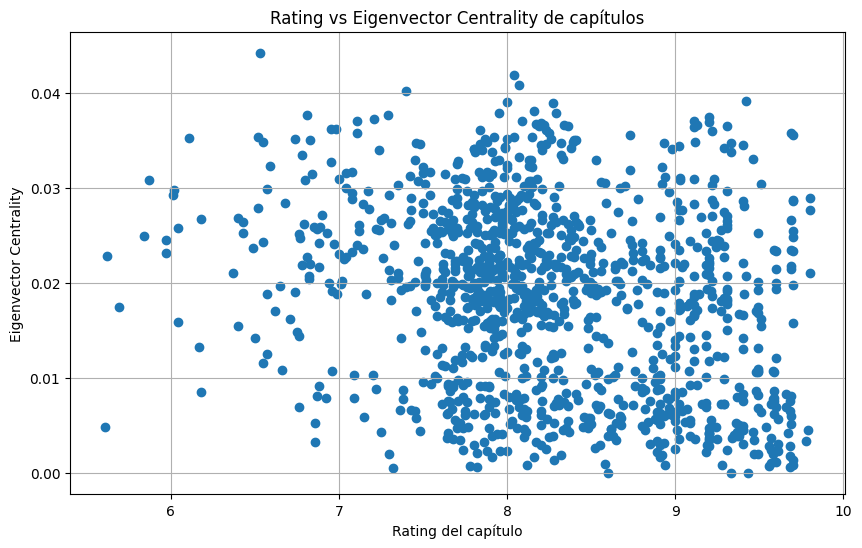

In [74]:
# Eigenvector centrality
centrality = nx.eigenvector_centrality(B, max_iter=1000,  weight='weight')

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(centrality[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Eigenvector Centrality")
plt.title("Rating vs Eigenvector Centrality de capítulos")

plt.grid(True)

plt.show()

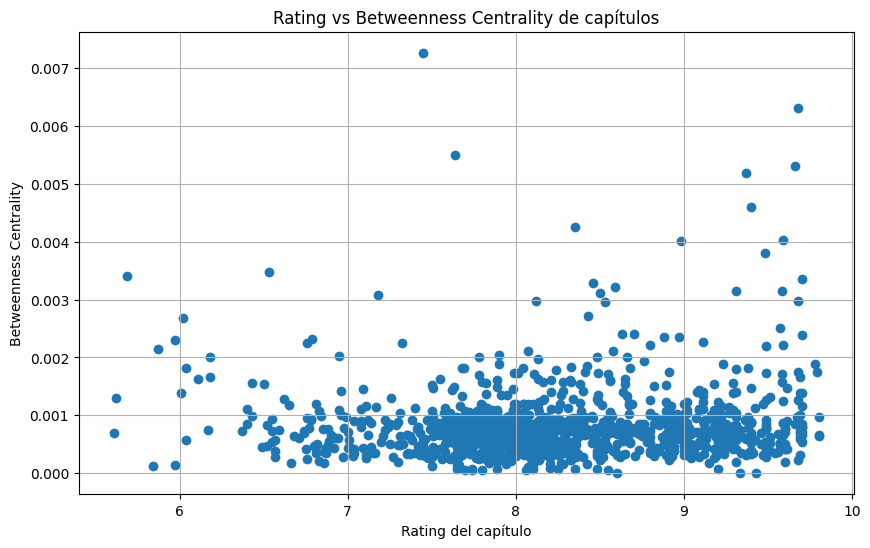

In [75]:
# Eigenvector centrality
centrality = nx.betweenness_centrality(B)

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(centrality[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Betweenness Centrality")
plt.title("Rating vs Betweenness Centrality de capítulos")

plt.grid(True)

plt.show()

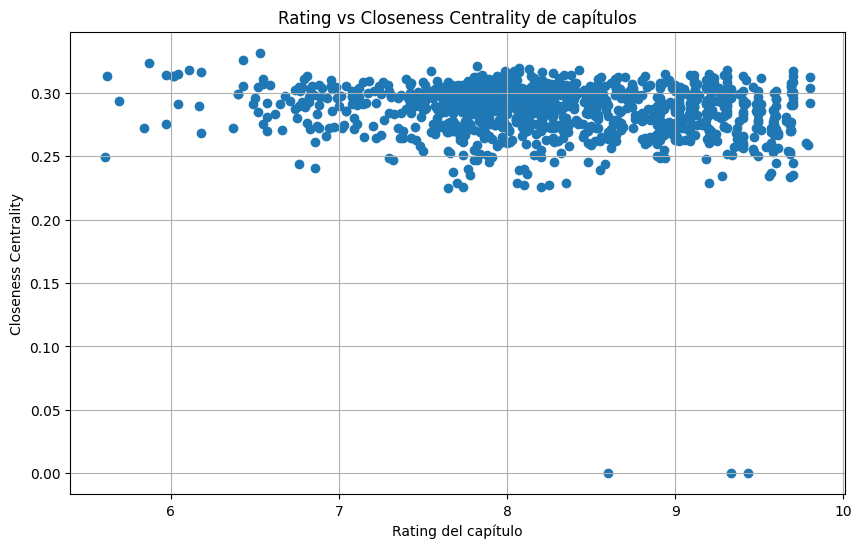

In [76]:
# Eigenvector centrality
centrality = nx.closeness_centrality(B)

# Extraer capítulos
ratings = []
centralities = []

for node, data in B.nodes(data=True):

    if data.get("bipartite") == "episode":

        rating = data.get("rating")

        if pd.notna(rating):

            ratings.append(rating)
            centralities.append(centrality[node])

# Scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(ratings, centralities)

plt.xlabel("Rating del capítulo")
plt.ylabel("Closeness Centrality")
plt.title("Rating vs Closeness Centrality de capítulos")

plt.grid(True)

plt.show()

Se procede a sacar la proyeccion del grafo, haciendo que solo queden las personas del staff.

In [77]:
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff = bipartite.weighted_projected_graph(B, staff_nodes)

print(f"Number of nodes: {G_staff.number_of_nodes()}, Number of edges: {G_staff.number_of_edges()}")
nx.write_gexf(G_staff, "one_piece_staff_projection.gexf")

Number of nodes: 233, Number of edges: 2869


Centralidad de grado

In [78]:
degree = dict(G_staff.degree())

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 109
Jin Tanaka 108
Kenji Yokoyama 101
Masayuki Takagi 85
Atsuhiro Tomioka 85
Miyuki Sato 85
Miho Shiraishi 79
Eisaku Inoue 79
Masahiro Shimanuki 78
Shōji Yonemura 77


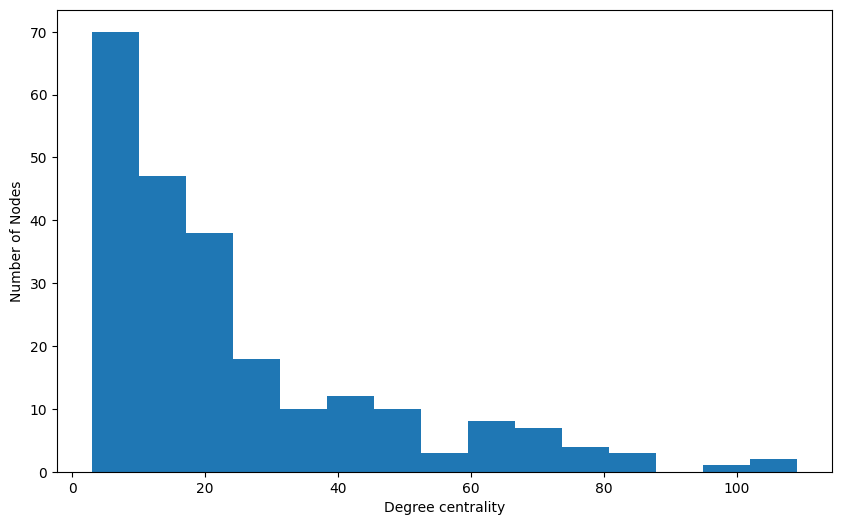

In [79]:
# Separar datos
personas = list(degree.keys())
grados = list(degree.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [80]:
degree = nx.degree_centrality(G_staff)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 0.4698275862068965
Jin Tanaka 0.46551724137931033
Kenji Yokoyama 0.4353448275862069
Masayuki Takagi 0.36637931034482757
Atsuhiro Tomioka 0.36637931034482757
Miyuki Sato 0.36637931034482757
Miho Shiraishi 0.34051724137931033
Eisaku Inoue 0.34051724137931033
Masahiro Shimanuki 0.33620689655172414
Shōji Yonemura 0.3318965517241379


Eigenvector centrality sin considerar peso de la arista

In [81]:
eigen = nx.eigenvector_centrality(G_staff)

top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Kazuya Hisada 0.1848969616885086
Kenji Yokoyama 0.18219159084974312
Jin Tanaka 0.17433882934432768
Masahiro Shimanuki 0.15862656552107704
Toshio Deguchi 0.154399129839487
Atsuhiro Tomioka 0.15222769579308795
Masayuki Takagi 0.15120681186464266
Miho Shiraishi 0.14575732467845762
Eisaku Inoue 0.14479185743740866
Tomohiro Nakayama 0.1444948969682262


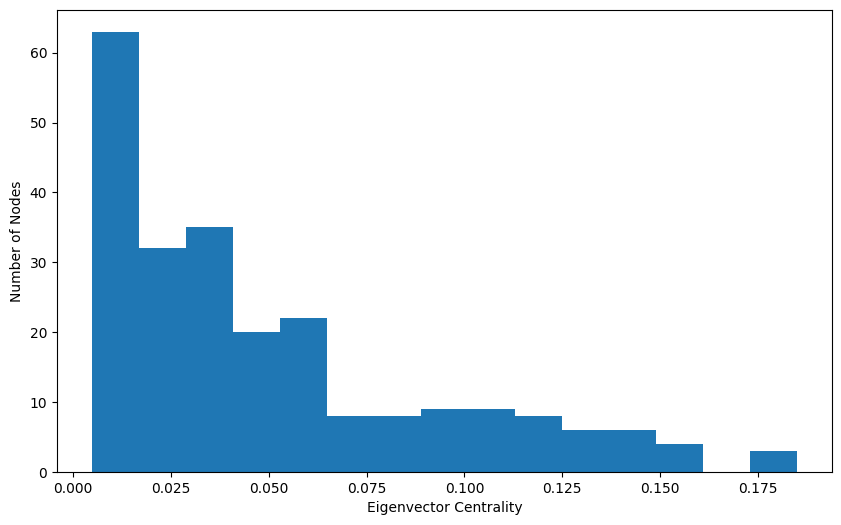

In [82]:
# Separar datos
personas = list(eigen.keys())
grados = list(eigen.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Eigenvector centrality considerando el peso de la arista

In [83]:
eigen = nx.eigenvector_centrality(G_staff, weight='weight')

top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Miyuki Sato 0.4043224400371667
Hirohiko Kamisaka 0.3084162827259964
Miho Shiraishi 0.30805801454522364
Ryūji Yoshiike 0.27237158792544564
Yoshiyuki Suga 0.2457575049798575
Kenji Yokoyama 0.21811318358527443
Masayuki Takagi 0.19884393830565525
Jin Tanaka 0.19683095333799777
Yoshihiro Ueda 0.18571039603630732
Michiyo Kawasaki 0.17649223668691102


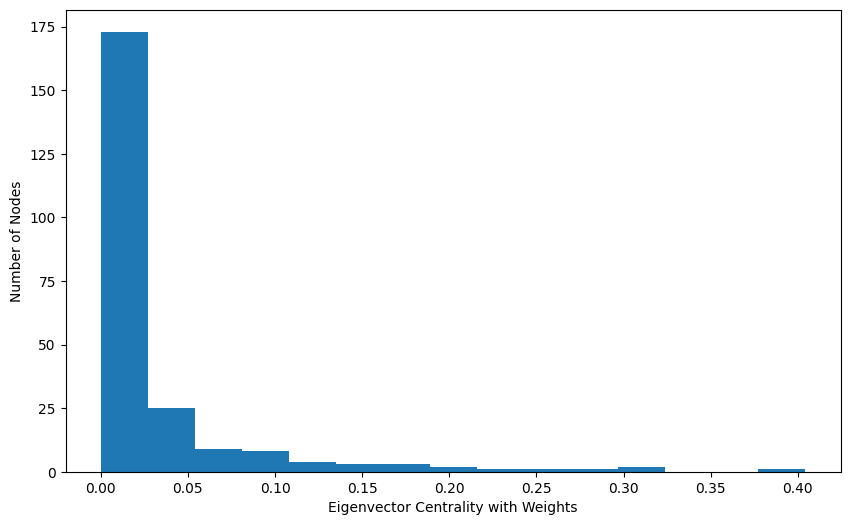

In [84]:
# Separar datos
personas = list(eigen.keys())
grados = list(eigen.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality with Weights")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Closeness

In [85]:
closeness = nx.closeness_centrality(G_staff)

top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6535211267605634
Jin Tanaka 0.651685393258427
Kenji Yokoyama 0.6391184573002755
Masayuki Takagi 0.6121372031662269
Masahiro Shimanuki 0.6010362694300518
Eisaku Inoue 0.6010362694300518
Miho Shiraishi 0.596401028277635
Atsuhiro Tomioka 0.5948717948717949
Toshio Deguchi 0.5918367346938775
Miyuki Sato 0.5903307888040712


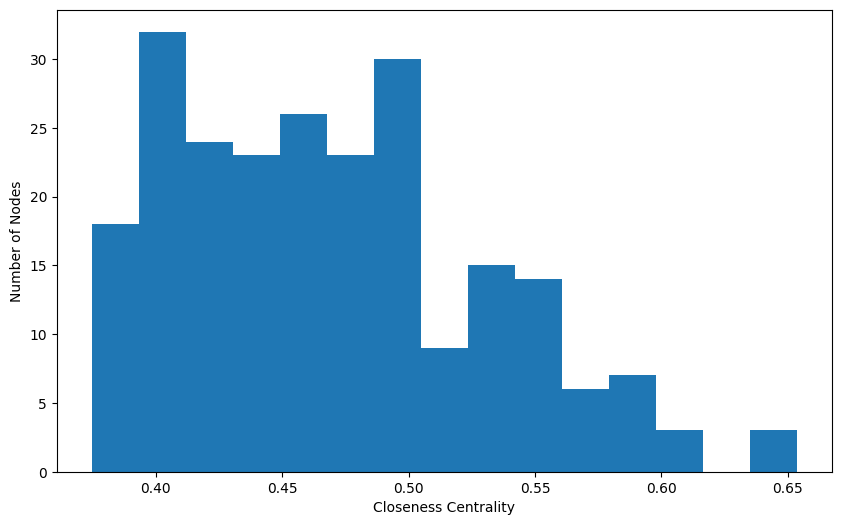

In [86]:
# Separar datos
personas = list(closeness.keys())
grados = list(closeness.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [87]:
betweenness = nx.betweenness_centrality(G_staff)

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.09675715238040525
Kazuya Hisada 0.09011684417969511
Miyuki Sato 0.06755054626850614
Kenji Yokoyama 0.057320164504382674
Eisaku Inoue 0.03955621350874956
Masayuki Takagi 0.03817290781804781
Masahiro Kitazaki 0.036795656100960195
Atsuhiro Tomioka 0.035247611055654486
Masahiro Shimanuki 0.0294576562596767
Hirohiko Kamisaka 0.029342377991245176


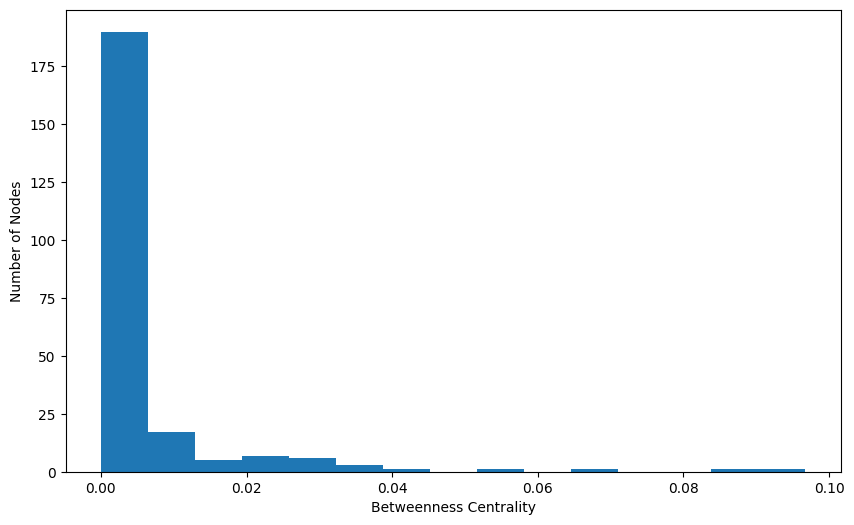

In [88]:
# Separar datos
personas = list(betweenness.keys())
grados = list(betweenness.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()